# Лабораторна робота №1
**Виконав:** Карпенко Артем Олександрович, Варіант 4

**Мета роботи:** Застосувати базові інструменти мови Python для розв'язання математичних задач. Опанувати алгоритми обчислення складних функцій з урахуванням області допустимих значень (ОДЗ), а також навчитися проводити векторизацію обчислень та візуалізувати результати за допомогою бібліотек `numpy` та `matplotlib`.

### 1. Аналіз функції та скалярні обчислення
Згідно з Варіантом 4, необхідно розрахувати та візуалізувати таку математичну функцію:

$$ p(x) = \frac{e^{-3x} + \tan(3x - 3)}{|\sin x| + \sqrt[4]{\cos x + \cos 2x}} $$

Математична модель заданої функції $p(x)$ вимагає суворого контролю вхідних параметрів. Під час програмної реалізації ми маємо запобігти виникненню системних помилок, обробивши дві ключові математичні сингулярності:

* **Обмеження підкореневого виразу:** Оскільки формула містить корінь парного (четвертого) ступеня, вираз $\cos x + \cos 2x$ обов'язково має бути невід'ємним. Якщо результат виявляється меншим за нуль, функція програмно перериває подальші розрахунки і генерує відповідне текстове повідомлення про помилку.
* **Захист від ділення на нуль:** Знаменник дробу не може дорівнювати нулю. Проте, враховуючи особливості представлення чисел із рухомою комою (floating-point arithmetic) в Python, тригонометричні операції з константою $\pi$ можуть давати мікроскопічну похибку замість абсолютного нуля. Тому перевірка знаменника реалізована через порівняння з гранично малим значенням (`< 0.000001`).

Для демонстрації написаного алгоритму, у наступному блоці коду реалізовано автоматизований прогін функції через п'ять різних контрольних значень $x$. Дані структуровані за допомогою словника, що дозволяє без дублювання коду вивести як математичні результати, так і коректно відловлені помилки ОДЗ.

In [10]:
import math

def calculate_p(x):
    numerator = math.exp(-3 * x) + math.tan(3 * x - 3)
    under_root = math.cos(x) + math.cos(2 * x)
    
    if under_root < 0:
        return "Помилка: від'ємне число під коренем"
        
    root_part = under_root ** 0.25
    sin_part = abs(math.sin(x))
    denominator = sin_part + root_part
    
    if denominator < 0.000001:
        return "Помилка: ділення на нуль"
    
    return numerator / denominator

x_values = {
    "0": 0,
    "1": 1,
    "2": 2,
    "pi/2": math.pi / 2,
    "pi": math.pi
}

print("Результати обчислень:")
for name, val in x_values.items():
    result = calculate_p(val)
    print(f"x = {name} ---> {result}")

Результати обчислень:
x = 0 ---> 0.960763292331684
x = 1 ---> 0.03469318524441641
x = 2 ---> Помилка: від'ємне число під коренем
x = pi/2 ---> Помилка: від'ємне число під коренем
x = pi ---> Помилка: ділення на нуль


### 2. Векторизація обчислень та візуалізація функції
Для побудови повноцінного графіка на заданому інтервалі $0 < x < 10$ ми переходимо від одиничних (скалярних) розрахунків до масової обробки даних. Використання масивів бібліотеки `numpy` дозволяє миттєво обчислити тисячі точок, не застосовуючи класичні цикли `for`.

**Ключові архітектурні рішення при побудові графіка:**
1. **Маскування невалідних значень:** Замість класичних умовних конструкцій `if`, застосовано функцію `np.where`. Вона аналізує весь вектор точок і там, де підкореневий вираз стає від'ємним, підставляє значення `np.nan` (Not a Number). Це дає вказівку графічній бібліотеці розірвати лінію, утворюючи природний математичний розрив.
2. **Оптимізація обчислень кореня:** Для запобігання генерації системних попереджень (`RuntimeWarning`), які виникають, коли `numpy` намагається превентивно обчислити корінь з від'ємних чисел для всього масиву, підкореневий вираз попередньо обробляється модулем `np.abs()`.
3. **Нейтралізація асимптот:** Складова функції $\tan(3x-3)$ має точки розриву, де її значення прямують до нескінченності. Щоб ці колосальні викиди не зламали візуальний масштаб графіка, амплітуда штучно обмежується — усі значення, які по модулю більші за 10, відсікаються. Це дозволяє детально розгледіти корисну ділянку графіка в межах осі Y від -3 до 3.

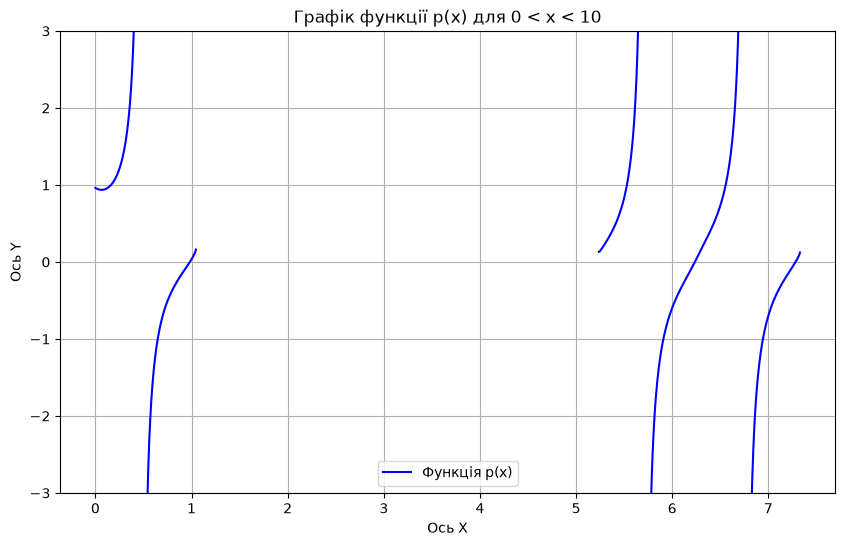

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_p_graph(x):
    numerator = np.exp(-3 * x) + np.tan(3 * x - 3)
    under_root = np.cos(x) + np.cos(2 * x)
    
    root_part = np.where(under_root >= 0, np.abs(under_root) ** 0.25, np.nan)
    sin_part = np.abs(np.sin(x))
    denominator = sin_part + root_part
    
    result = np.where(denominator > 0.000001, numerator / denominator, np.nan)
    result = np.where(np.abs(result) > 10, np.nan, result)
    
    return result

x_points = np.linspace(0, 10, 2000)
y_points = calculate_p_graph(x_points)

plt.figure(figsize=(10, 6))
plt.plot(x_points, y_points, color='blue', label='Функція p(x)')
plt.title('Графік функції p(x) для 0 < x < 10')
plt.xlabel('Ось X')
plt.ylabel('Ось Y')
plt.ylim(-3, 3) 
plt.grid(True)
plt.legend()
plt.show()

### Висновок
У результаті виконання лабораторної роботи було створено комплексний алгоритм, який не лише виконує математичні обчислення, але й стійко реагує на обмеження області допустимих значень. 

Візуалізація масиву даних за допомогою `matplotlib` повністю підтверджує аналітичні розрахунки: побудована крива має чіткі розриви на проміжках (зокрема, від $x \approx 1$ до $x \approx 5.2$), де вираз під коренем набуває від'ємних значень і функція не існує. Завдяки векторизації через `numpy` та правильній програмній обробці асимптот тангенса, отриманий графік є математично точним, коректно масштабованим та позбавленим візуальних артефактів, що свідчить про успішне виконання всіх поставлених завдань.